# LEARNING OBJECTIVE

This notebook shows how to understand Poiseuille&ndash;Couette (PC) flow underneath a slipper pad bearing, under the lubrication approximation. This notebook builds on the previous demonstration of unidirectional PC flow in a straight channel. The velocity profile and the nonlinear pressure distribution generated by the lubrication flow are visualized.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [1]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# ploting customizations
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# for Colab only: to save plots as files and download them
#from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# FLOW GENERATED UNDER A MOVING SLIPPER PAD

A 2D slipper pad with rigid, angled side extend infinitely out of the page. The characteristic height of the fluid layer under the slipper pad is $h_0$. The distance between the lower rigid wall and the slipper pad's angled side is $h(x) = h_0 + (h_L - h_0)x/L$.  The axial length of the slipper pad is $L$.

The dimensional lubrication equations are
\begin{alignat*}{3}
    \text{[COM]}\qquad &&\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} &= 0,\\
    \text{[COLM-$x$]}\qquad &&0 &\approx -\frac{\partial p}{\partial x} + \mu \frac{\partial^2 u}{\partial y^2},\\
    \text{[COLM-$y$]}\qquad &&0 &\approx -\frac{\partial p}{\partial y}.
\end{alignat*}
The boundary conditions (no slip, no penetration, uniform pressure outside the slipper pad) are
\begin{align*}
    u(x,y=0) &= 0,\\
    v(x,y=0) &= 0.\\
    u\big(x,y=h(x)\big) &= U,\\
    v\big(x,y=h(x)\big) &= V,\\
    p(x=0,y) &= p_0,\\
    p(x=L,y) &= p_0.
\end{align*}

The solution of COLM-$y$ subject to these boundary conditions is once again the combined Poiseuille&ndash;Couette flow, but with $h=h(x)$:
$$
    u(x,y) = U \frac{y}{h(x)} + \frac{[h(x)]^2}{2\mu}\left(-\frac{\partial p}{\partial x}\right) \left[ \frac{y}{h(x)} - \left(\frac{y}{h(x)}\right)^2 \right],
$$
where the pressure $p(x)$ is currently unknown. We'll keep using partial derivatives for clarity, but most quantities are only functions of $x$.

From COM, we have
\begin{align*}
    v(x,y) &= - \int_0^y \frac{\partial u}{\partial x} dy \\
           &= \frac{U}{2} \left(\frac{y}{h(x)}\right)^2 
           + \frac{1}{2\mu} \left(-\frac{\partial^2 p}{\partial x^2}\right)\left[h(x) y - y^2 \right]
           + \frac{1}{2\mu} \left(-\frac{\partial p}{\partial x}\right) \frac{\partial h}{\partial x} y 
\end{align*}
But also using the boundary condition
\begin{align*}
    V &= - \int_0^{h(x)} \frac{\partial u}{\partial x} dy \\
      &\overbrace{=}^{\text{Leibniz}} - \frac{\partial }{\partial x} \int_0^{h(x)} u(x,y) dy + \underbrace{u\big(x,y=h(x)\big)}_{U}\frac{\partial h}{\partial x} \\
      &= - \frac{\partial }{\partial x} \left\{ U \frac{h(x)}{2} - \frac{[h(x)]^3}{12\mu} \frac{\partial p}{\partial x} \right\} + U \frac{\partial h}{\partial x} \\
      &= \frac{\partial }{\partial x} \left\{ \frac{[h(x)]^3}{12\mu} \frac{\partial p}{\partial x} \right\} + \frac{U}{2} \frac{\partial h}{\partial x}.
\end{align*}

The last equation can be integrated to find the pressure:
$$
    V x - \frac{U}{2} h(x) = \frac{[h(x)]^3}{12\mu}\frac{\partial p}{\partial x} + C_1,
$$
or
$$
    \frac{12\mu}{[h(x)]^3} \left[ V x - \frac{U}{2} h(x) - C_1 \right] = \frac{\partial p}{\partial x},
$$
or
$$
    p(x) = \int_0^x \frac{12\mu}{[h(x)]^3} \left[ V x - \frac{U}{2} h(x) - C_1 \right] dx + p_0.
$$
Note that $C_1$ is truly a _constant_, not a function, of integration.

Let's make it dimensionless:
$$
    p^*(x^*) = \frac{p(x) - p_0}{\mu U L/h_0^2} = 12\int_0^{x^*} \frac{1}{[h^*(x^*)]^3} \left[  \frac{V L}{h_0 U} x^* - \frac{1}{2}h^*(x^*) - C_1^* \right] dx^*.
$$
Here, $x^* = x/L$ and $h^*(x^*) = h(x)/h_0$, and ${V L}/{h_0 U} = V^*$ is a dimensionless parameter we can vary. 

The pressure is subject to the final boundary condition $p^*(1) = 0$, thus
$$
    C_1^* = \frac{\int_0^1 \frac{1}{[h^*(x^*)]^3} \left[ V^* x^* - \frac{1}{2} h^*(x^*) \right] dx^*}{\int_0^1 \frac{1}{[h^*(x^*)]^3} dx^*}.
$$

# PRESSURE FOR GIVEN GAP SHAPE

In [2]:
xs, x, C1s, Vs, alpha = sp.symbols('x^*, x, C_1^*, V^*, alpha')
hs = 1 + alpha*xs

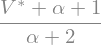

In [3]:
C1s = sp.integrate((Vs*xs+hs/2)/hs**3,(xs,0,1))/sp.integrate(1/hs**3,(xs,0,1))
C1s.simplify()

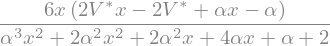

In [4]:
ps = 12*sp.integrate((Vs*xs+hs/2-C1s)/hs**3,(xs,0,x))
ps.simplify()

In [5]:
ps0 = sp.limit(ps,alpha,0)
ps0.simplify()

In [6]:
lam_p = sp.lambdify([x, Vs, alpha], ps)
lam_p0 = sp.lambdify([x, Vs], ps0)
lam_h = sp.lambdify([x, alpha], hs.subs(xs,x))

# VISUALIZATION

I will use a [`quiver`](https://matplotlib.org/stable/gallery/images_contours_and_fields/quiver_simple_demo.html) plot to show the velocity arrows, and a regular line plot to show he envelope of the vectors.

In [7]:
def plot_func(Vs,α):
  # x^* goes from 0 to 1
  xp = np.linspace(0, 1, num=100)

  fig, ax = plt.subplots(tight_layout=True)
  ax.set_ylabel(r'$p^* = \frac{p - p_0}{\mu U L/h_0^2}$')
  ax.set_ylim(-3,6) # might have to be judicious
  ax.set_xlabel('$x^* = x/L$')
  ax.set_xlim(0,1)
  
  # handle α = 0 case separately as a limit
  if α != 0:
    ax.plot(xp,lam_p(xp,Vs,α))
  else:
    ax.plot(xp,lam_p0(xp,Vs))
  
  ax.plot(xp,lam_h(xp,α),color='gray',linestyle='dashed',label='$h^*(x^*)$')
          
  # show a grid to make it easier to see where the y=0 interface is
  ax.grid(alpha=0.5, linestyle='dotted')

  ax.legend()

  plt.show()

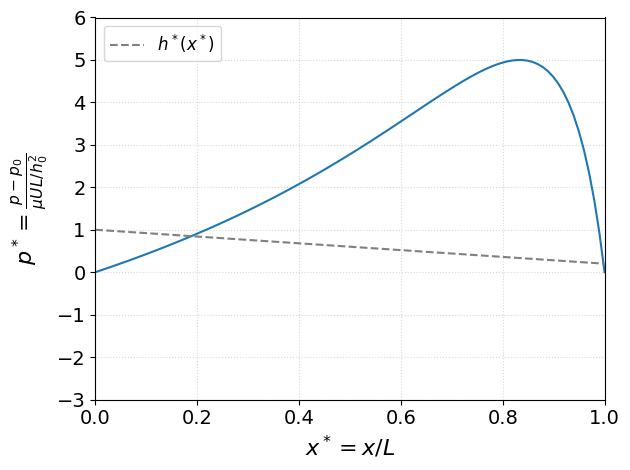

In [8]:
plot_func(0,-0.8)

An [`interact`](https://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html) widget will let us vary $\alpha$ and $V^*$.

In [9]:
interact(plot_func, Vs = widgets.FloatSlider(value=0,
                                             min=-1,
                                             max=+1,
                                             step=0.1),
                    α = widgets.FloatSlider(value=-0.5,
                                             min=-1,
                                             max=1,
                                             step=0.1));

interactive(children=(FloatSlider(value=0.0, description='Vs', max=1.0, min=-1.0), FloatSlider(value=-0.5, des…

# FURTHER EXPLORATION

On your own:

*   Try different $h^*(x^*)$ shapes, such as
    - $h^*(x^*) = e^{\alpha x^*}$.
    - $h^*(x^*) = \begin{cases} 1, &0\le x^* \le 1/2,\\ \alpha, &1/2 < x^* \le 1.\end{cases}$
*   Plot the velocity field in the gap.
